In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pip install pydataset

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 80.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pydataset: filename=pydataset-0.2.0-py3-none-any.whl size=15939415 sha256=3d5f7f6532edafb26c5f3aa648c49187a11a4f1874d56d7e487c79501a03821a
  Stored in directory: /root/.cache/pip/wheels/4c/82/ad/f04abc617222b10438b1285ab9b5cfaecd180c10a7c81cff54
Successfully built pydataset


In [4]:
from pydataset import data

initiated datasets repo at: /root/.pydataset/


In [5]:
df = data("HairEyeColor")

In [6]:
df

,Hair,Eye,Sex,Freq
1,Black,Brown,Male,32
2,Brown,Brown,Male,53
3,Red,Brown,Male,10
4,Blond,Brown,Male,3
5,Black,Blue,Male,11
6,Brown,Blue,Male,50
7,Red,Blue,Male,10
8,Blond,Blue,Male,30
9,Black,Hazel,Male,10
10,Brown,Hazel,Male,25


In [7]:
df['Hair'].unique()

array(['Black', 'Brown', 'Red', 'Blond'], dtype=object)

# if we want to convert the abouve output(array) in to list , just use the below given function.

In [8]:
df['Hair'].unique().tolist()

['Black', 'Brown', 'Red', 'Blond']

In [9]:
df['Hair'].nunique()

4

In [10]:
df.columns

Index(['Hair', 'Eye', 'Sex', 'Freq'], dtype='object')

In [11]:
df.columns.tolist()

['Hair', 'Eye', 'Sex', 'Freq']

In [12]:
for col in ['Hair', 'Eye', 'Sex']:
  print(df[col].unique())
  print(df[col].nunique())

['Black' 'Brown' 'Red' 'Blond']
4
['Brown' 'Blue' 'Hazel' 'Green']
4
['Male' 'Female']
2


In [13]:
df.head()

,Hair,Eye,Sex,Freq
1,Black,Brown,Male,32
2,Brown,Brown,Male,53
3,Red,Brown,Male,10
4,Blond,Brown,Male,3
5,Black,Blue,Male,11


In [14]:
df.shape

(32, 4)

In [15]:
df.dtypes

,0
Hair,object
Eye,object
Sex,object
Freq,int64


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, 1 to 32
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Hair    32 non-null     object
 1   Eye     32 non-null     object
 2   Sex     32 non-null     object
 3   Freq    32 non-null     int64 
dtypes: int64(1), object(3)
memory usage: 1.2+ KB


##EDA

In [17]:
df.head(2)

,Hair,Eye,Sex,Freq
1,Black,Brown,Male,32
2,Brown,Brown,Male,53


In [18]:
df.groupby("Hair")["Freq"].sum()

,Freq
Hair,
Black,108
Blond,127
Brown,286
Red,71


##The output given is in series in we want to change it in dataframe, then run the below command

In [19]:
df.groupby("Hair")["Freq"].sum().reset_index()

,Hair,Freq
0,Black,108
1,Blond,127
2,Brown,286
3,Red,71


Assigning a variable

In [20]:
df_hair = df.groupby("Hair")["Freq"].sum()

In [21]:
df_hair = df.groupby("Hair")["Freq"].sum().reset_index()

In [22]:
df_hair

,Hair,Freq
0,Black,108
1,Blond,127
2,Brown,286
3,Red,71


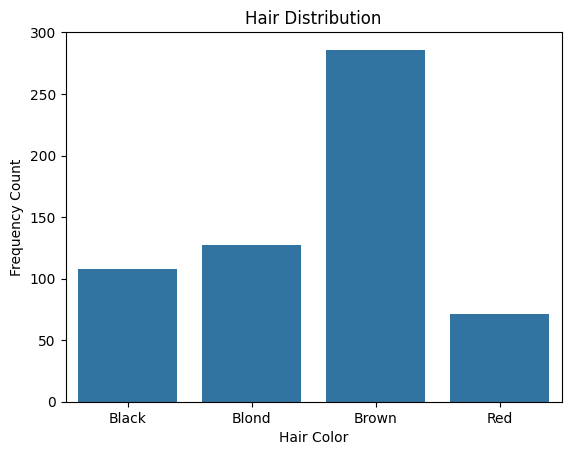

In [23]:
sns.barplot(data=df_hair,
            x= "Hair",
            y="Freq")
plt.title("Hair Distribution")
plt.ylabel("Frequency Count")
plt.xlabel("Hair Color")
plt.show()

In [24]:
df.groupby("Eye")["Freq"].sum()

,Freq
Eye,
Blue,215
Brown,220
Green,64
Hazel,93


In [25]:
df.groupby("Eye")["Freq"].sum().reset_index()

,Eye,Freq
0,Blue,215
1,Brown,220
2,Green,64
3,Hazel,93


In [26]:
df_eye = df.groupby("Eye")["Freq"].sum().reset_index()

In [27]:
df_eye

,Eye,Freq
0,Blue,215
1,Brown,220
2,Green,64
3,Hazel,93


### Eye Distribution

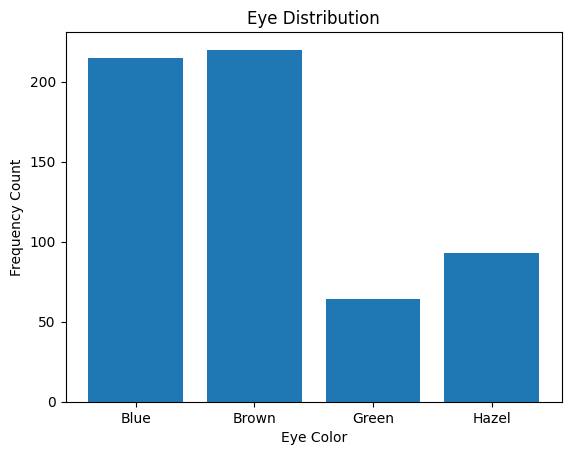

In [28]:
plt.bar( x = df_eye["Eye"],
        height = df_eye["Freq"]        )
plt.title("Eye Distribution")
plt.ylabel("Frequency Count")
plt.xlabel("Eye Color")
plt.show()

In [29]:
df.head()

,Hair,Eye,Sex,Freq
1,Black,Brown,Male,32
2,Brown,Brown,Male,53
3,Red,Brown,Male,10
4,Blond,Brown,Male,3
5,Black,Blue,Male,11


In [30]:
pivot_data = df.groupby(["Hair", "Eye"])["Freq"].sum()

In [31]:
pivot_data

Hair   Eye  
Black  Blue      20
       Brown     68
       Green      5
       Hazel     15
Blond  Blue      94
       Brown      7
       Green     16
       Hazel     10
Brown  Blue      84
       Brown    119
       Green     29
       Hazel     54
Red    Blue      17
       Brown     26
       Green     14
       Hazel     14
Name: Freq, dtype: int64

Here, we got the data as a series, to change it into dataframe follow below steps

In [32]:
pivot_data = df.groupby(["Hair", "Eye"])["Freq"].sum().unstack()

In [33]:
pivot_data

Eye,Blue,Brown,Green,Hazel
Hair,,,,
Black,20,68,5,15
Blond,94,7,16,10
Brown,84,119,29,54
Red,17,26,14,14


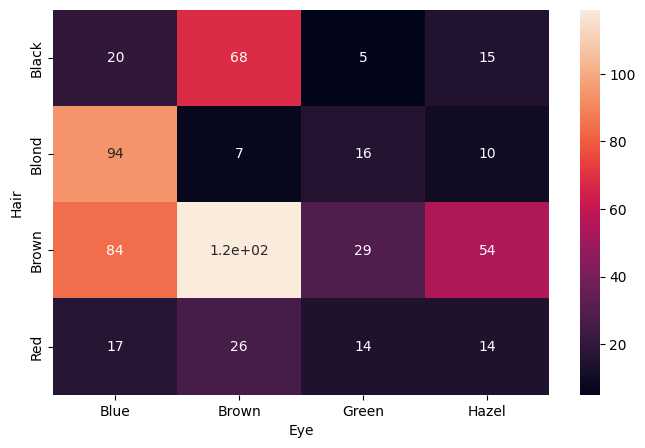

In [34]:
plt.figure(figsize=(8, 5))
sns.heatmap(data = pivot_data, annot = True)
plt.show()

1.2e +02 is read as 1.2 Multiply 10 power 2 (i.e 120)

### Hair and Eye distribution

In [35]:
df_hair = df.groupby(["Hair","Sex"])["Freq"].sum().reset_index()
df_hair

,Hair,Sex,Freq
0,Black,Female,52
1,Black,Male,56
2,Blond,Female,81
3,Blond,Male,46
4,Brown,Female,143
5,Brown,Male,143
6,Red,Female,37
7,Red,Male,34


In [36]:
df_eye = df.groupby(["Eye","Sex"])["Freq"].sum().reset_index()
df_eye

,Eye,Sex,Freq
0,Blue,Female,114
1,Blue,Male,101
2,Brown,Female,122
3,Brown,Male,98
4,Green,Female,31
5,Green,Male,33
6,Hazel,Female,46
7,Hazel,Male,47


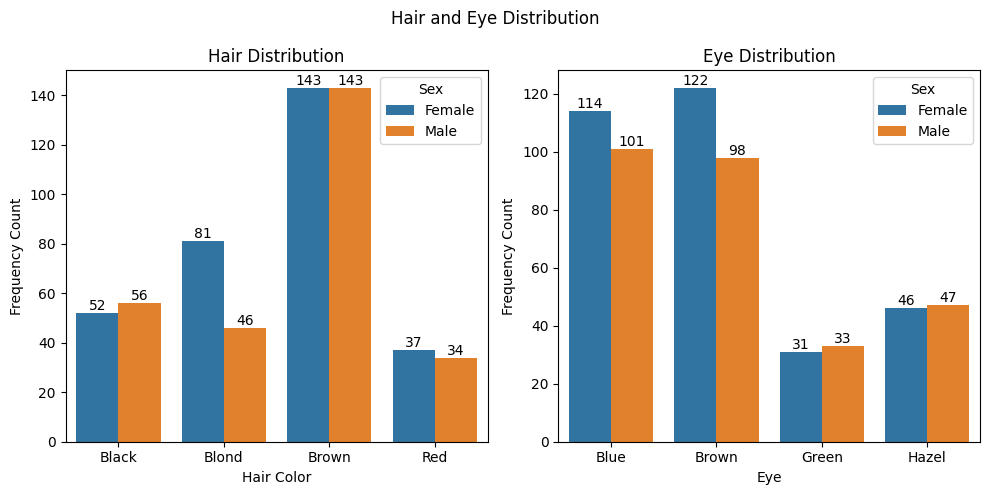

In [41]:
fig, axes = plt.subplots(1,2, figsize=(10,5))

sns.barplot(data=df_hair,
            x="Hair",
            y="Freq",
            hue="Sex",
            ax=axes[0])
axes[0].set_title("Hair Distribution")
axes[0].set_ylabel("Frequency Count")
axes[0].set_xlabel("Hair Color")


for bar in axes[0].containers:
  axes[0].bar_label(bar)


sns.barplot(data=df_eye,
            x="Eye",
            y="Freq",
            hue="Sex",
            ax=axes[1])
axes[1].set_title("Eye Distribution")
axes[1].set_ylabel("Frequency Count")


for bar in axes[1].containers:
  axes[1].bar_label(bar)


plt.suptitle("Hair and Eye Distribution")
plt.tight_layout()
plt.show()